IMPORTING REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from datetime import datetime
import matplotlib.dates as mdates


DATA PREPROCESSING

In [2]:
df = pd.read_csv('D:\gold_etf_dataset.csv')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.sort_values('Date', inplace=True)

print(df.isnull().sum())

df['Change%'].fillna(method='ffill', inplace=True)

df.info()


Date       0
Price      0
Open       0
High       0
Low        0
Vol        0
Change%    1
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3904 non-null   datetime64[ns]
 1   Price    3904 non-null   float64       
 2   Open     3904 non-null   float64       
 3   High     3904 non-null   float64       
 4   Low      3904 non-null   float64       
 5   Vol      3904 non-null   int64         
 6   Change%  3903 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 213.6 KB


C:\Users\kamal\AppData\Local\Temp\ipykernel_15004\1045517652.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Change%'].fillna(method='ffill', inplace=True)
C:\Users\kamal\AppData\Local\Temp\ipykernel_15004\1045517652.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Change%'].fillna(method='ffill', inplace=True)


EXPLORATORY DATA ANALYSIS (EDA)

                                Date        Price         Open         High  \
count                           3904  3904.000000  3904.000000  3904.000000   
mean   2017-10-04 08:43:01.967213312   151.245838   151.243594   151.912743   
min              2010-01-04 00:00:00   100.500000   100.919998   100.989998   
25%              2013-11-17 06:00:00   120.892502   120.897501   121.397501   
50%              2017-10-03 12:00:00   140.860001   140.715004   141.709999   
75%              2021-08-19 06:00:00   169.939995   170.075005   170.654995   
max              2025-07-11 00:00:00   316.290008   317.489990   317.630005   
std                              NaN    39.910058    39.894700    40.073864   

               Low           Vol      Change%  
count  3904.000000  3.904000e+03  3903.000000  
mean    150.522305  9.670239e+06     0.031322  
min     100.230003  1.436500e+06    -8.780000  
25%     120.447498  5.834825e+06    -0.485000  
50%     140.160004  8.145900e+06     0.050000  


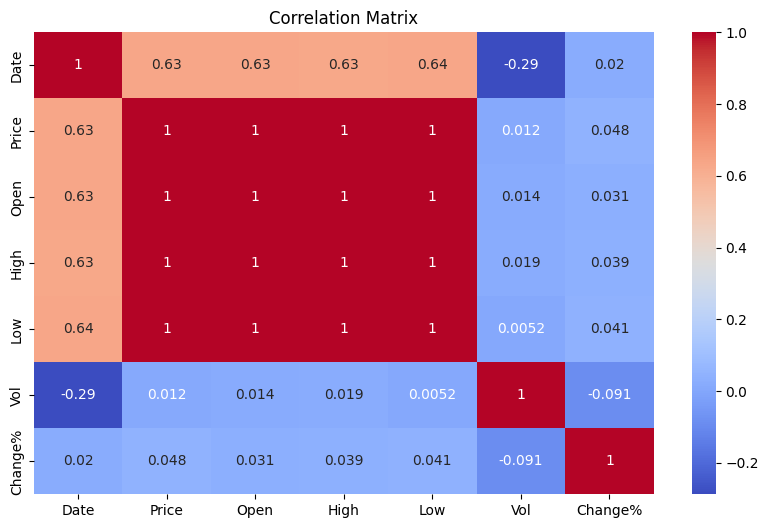

In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print(df.describe())

fig = px.line(df, x='Date', y='Price', title='Gold Price Over Time')
fig.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

fig = px.scatter(df, x='Vol', y='Price', title='Volume vs Price')
fig.show()

df['MA50'] = df['Price'].rolling(window=50).mean()
df['MA200'] = df['Price'].rolling(window=200).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Price'], mode='lines', name='Price'))
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA50'], mode='lines', name='MA50'))
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA200'], mode='lines', name='MA200'))
fig.update_layout(title='Price with Moving Averages', xaxis_title='Date', yaxis_title='Price')
fig.show()


FEATURE ENGINEERING 

In [4]:

data = df[['Price']]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

training_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]


In [5]:
# Save scaler
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save scaled data
np.save("scaled_data.npy", scaled_data)


SEQUENCE FOR LSTM 

In [6]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


MODEL TRAINING 

In [7]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

history = model.fit(X_train, y_train, batch_size=64, epochs=30, validation_data=(X_test, y_test))


C:\Users\kamal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0112 - val_loss: 0.0023
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 6.2702e-04 - val_loss: 5.5308e-04
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 5.6649e-04 - val_loss: 7.2757e-04
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 4.9053e-04 - val_loss: 7.7450e-04
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 4.1348e-04 - val_loss: 5.1968e-04
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.5373e-04 - val_loss: 9.0338e-04
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.2835e-04 - val_loss: 7.3994e-04
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 3.6126e-04 - val_loss: 0.0012
Epoch 9/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 3.0212e-04 - val_loss: 9.6335e-04
Epoch 10/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 3.0397e-04 - val_loss: 0.0011
Epoch 11/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.8748e-04 - val_loss: 7.

In [8]:
model.save("gold_price_model.h5")
print("✅ Model saved as gold_price_model.h5")


✅ Model saved as gold_price_model.h5


EVALUATION 

In [9]:

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
y_train_scaled = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_scaled = scaler.inverse_transform([y_test])

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_scaled[0], train_predict[:, 0])))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_scaled[0], test_predict[:, 0])))



y_test_actual = scaler.inverse_transform([y_test])[0]
y_test_predicted = test_predict[:, 0]
mape = mean_absolute_percentage_error(y_test_actual, y_test_predicted) * 100
print(f"MAPE on Test Set: {mape:.2f}%")


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Train RMSE: 2.240528536166154
Test RMSE: 5.332191043396754
MAPE on Test Set: 1.62%


EVALUATION METRICIES 

In [10]:
y_test_actual = scaler.inverse_transform([y_test])[0]
# Already inverse transformed test predictions: test_predict[:, 0]
y_pred_actual = test_predict[:, 0]

# Evaluation Metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

# Print Metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# Derived Accuracy
accuracy = (1 - mape) * 100
print(f"Prediction Accuracy: {accuracy:.2f}%")

Mean Squared Error (MSE): 28.4323
Root Mean Squared Error (RMSE): 5.3322
Mean Absolute Error (MAE): 3.7577
Mean Absolute Percentage Error (MAPE): 0.0162
R-squared (R²): 0.9851
Prediction Accuracy: 98.38%


VISUALIZATION 

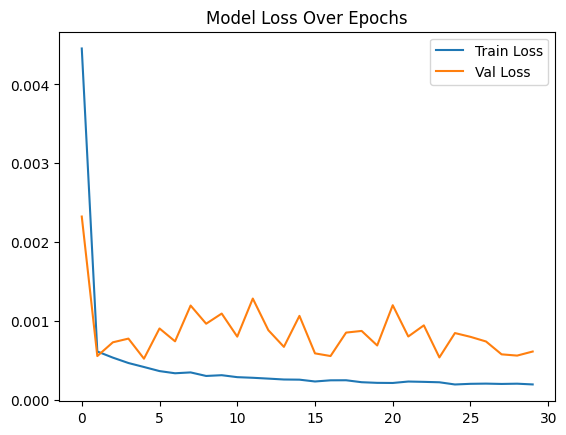

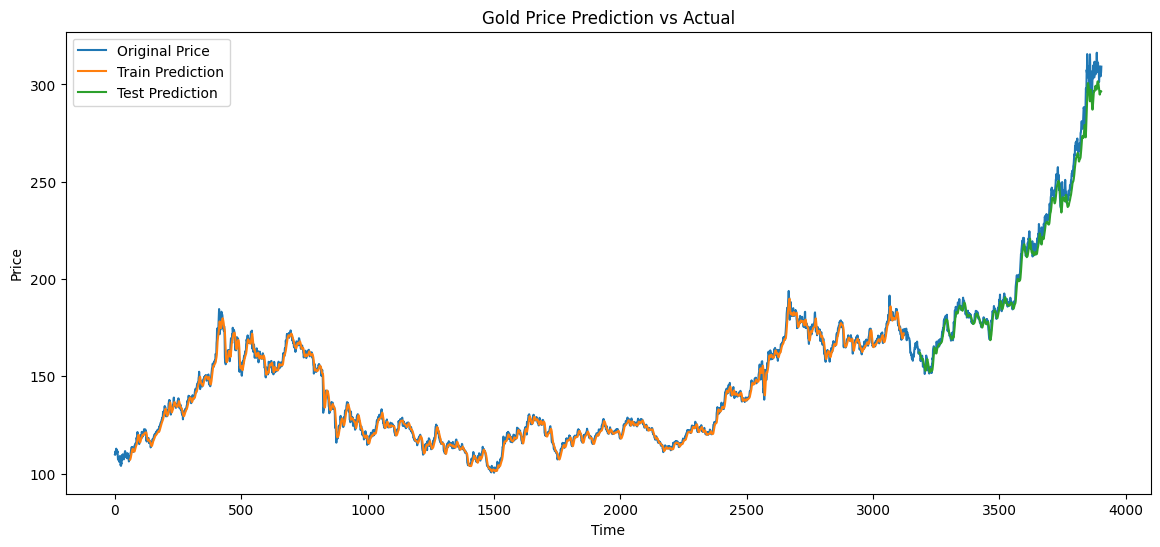

In [11]:

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Model Loss Over Epochs")
plt.show()

train_plot = np.empty_like(scaled_data)
train_plot[:, :] = np.nan
train_plot[time_step:len(train_predict) + time_step, 0] = train_predict[:, 0]

test_plot = np.empty_like(scaled_data)
test_plot[:, :] = np.nan
test_plot[len(train_predict) + (time_step*2) + 1:len(scaled_data)-1, 0] = test_predict[:, 0]

plt.figure(figsize=(14, 6))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Price')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.legend()
plt.title("Gold Price Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()


PREDICTED PRICE GRAPH

In [12]:
last_60_days = scaled_data[-60:]
input_seq = last_60_days.reshape(1, -1)[0].tolist()

future_output = []
for _ in range(366):
    x_input = np.array(input_seq[-60:]).reshape(1, 60, 1)
    prediction = model.predict(x_input, verbose=0)
    input_seq.append(prediction[0][0])
    future_output.append(prediction[0][0])

future_prices = scaler.inverse_transform(np.array(future_output).reshape(-1, 1))

future_dates = pd.date_range(start='2026-01-01', periods=366)

future_df = pd.DataFrame({'Date': future_dates, 'Predicted Price': future_prices.flatten()})

fig = px.line(future_df, x='Date', y='Predicted Price', title='Predicted Gold Prices for 2026')
fig.show()